# Lab 3: K-Nearest Neighbors Classifier
In this notebook, we load the preprocessed Titanic dataset, implement a KNN Classifier,
perform a hyperparameter sweep for K from 1 to 25, and plot the Error Rate vs K Value.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## 1. Load Processed Data

In [ ]:
df = pd.read_csv('data/titanic_processed.csv')
print(f"Data shape: {df.shape}")

if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

X = df.drop(columns=['Survived'])
y = df['Survived']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Data shape: (891, 10)


## 2. KNN Implementation and Hyperparameter Sweep (K=1 to 25)

In [ ]:
error_rates = []

k_values = range(1, 26)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    # Error rate = 1 - accuracy
    error = 1.0 - accuracy_score(y_test, y_pred)
    error_rates.append(error)

print("Error rates for K=1 to 25 calculated.")

Error rates for K=1 to 25 calculated.


## 3. Plot Error Rate vs K Value

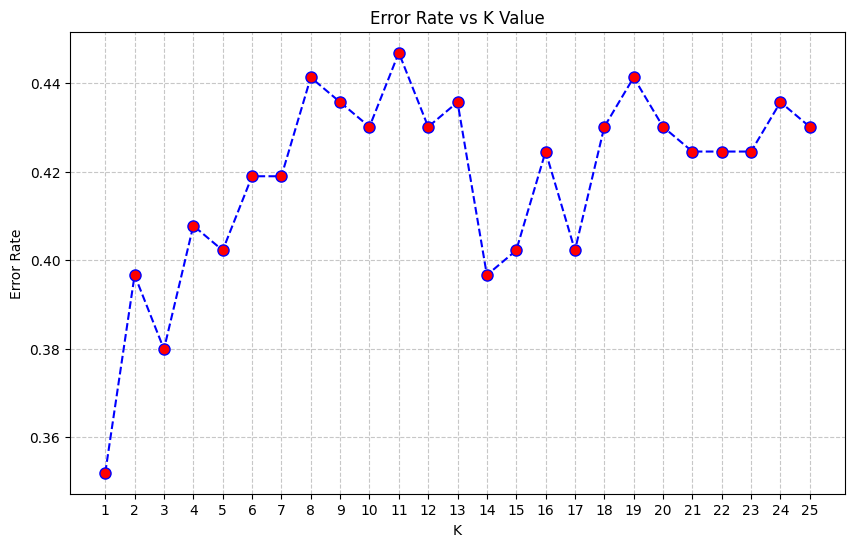

Optimal K value is: 1
Minimum Error Rate is: 0.3520
Plot saved to knn_error_rate_vs_k.png


In [ ]:
plt.figure(figsize=(10,6))
plt.plot(k_values, error_rates, marker='o', linestyle='dashed', color='blue', markerfacecolor='red', markersize=8)
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(list(k_values))
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('knn_error_rate_vs_k.png')
plt.show()

# Find optimal K (minimum error rate)
optimal_k = k_values[np.argmin(error_rates)]
min_error = min(error_rates)

print(f"Optimal K value is: {optimal_k}")
print(f"Minimum Error Rate is: {min_error:.4f}")
print("Plot saved to knn_error_rate_vs_k.png")